# Lab 01 - Classifying Spam Emails

Notebook này được tổ chức theo từng step giống notebook mẫu: load data, EDA trước balance, preprocessing/balance, EDA sau balance, feature engineering, train model, evaluate, tune/check, và deploy.

## Step 0 — Import Libraries And Setup

In [2]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
PROJECT_ROOT

crawl module: /Users/quangmanh/Project/lab01/notebooks/crawl.py
preprocess module: /Users/quangmanh/Project/lab01/notebooks/preprocess.py
model module: /Users/quangmanh/Project/lab01/notebooks/model_from_scratch.py
eda module: /Users/quangmanh/Project/lab01/notebooks/eda.py


## Step 1 — Raw/Processed Data: Load Dataset

Load dữ liệu raw và dữ liệu đã xử lý/balance hiện có trong project.

In [4]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
overview = crawl.dataset_overview(data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")
display(data.head(3))

Processed rows: 9,886
Raw rows: 18,807
                                            email_id  ... clean_word_count
0  71d2056787e4c1e3e1c5b4902fc41127243bbf63c778ed...  ...              112
1  493bcce942bedc9f6f624788fe981c0ca0684bf066ae48...  ...               29
2  f9a91ae7262fc1af4c7cada985dd975afa560b73cc020d...  ...              374

[3 rows x 18 columns]


### Step 1.4 — Data V2 Merge And 9-Matrix Comparison

Merge extra ham from `data_v2` into the training pool only, keep the original test set fixed, and compare 3 training datasets across 3 models.


                                 dataset   rows   ham  spam  source_families
0    data_v1 train before mode transform   7908  4345  3563               11
1  data_v2 extra ham added to train only   5809  5809     0                2
2                        V2 merged train  13236  9673  3563               13
3                     fixed data_v1 test   1978  1088   890               11
  training_mode  train_rows  ham_train  spam_train  source_families
0      Balanced        7126       3563        3563               11
1    Unbalanced        7908       4345        3563               11
2     V2 merged       13236       9673        3563               13
label                                 ham  spam
source_family                                  
aueb_enron1_spam_ham                  385   361
aueb_enron2_spam_ham                  392   389
aueb_enron3_spam_ham                  393   394
aueb_enron4_spam_ham                  390   354
aueb_enron5_spam_ham                  370   239
aueb_en

<string>:166: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


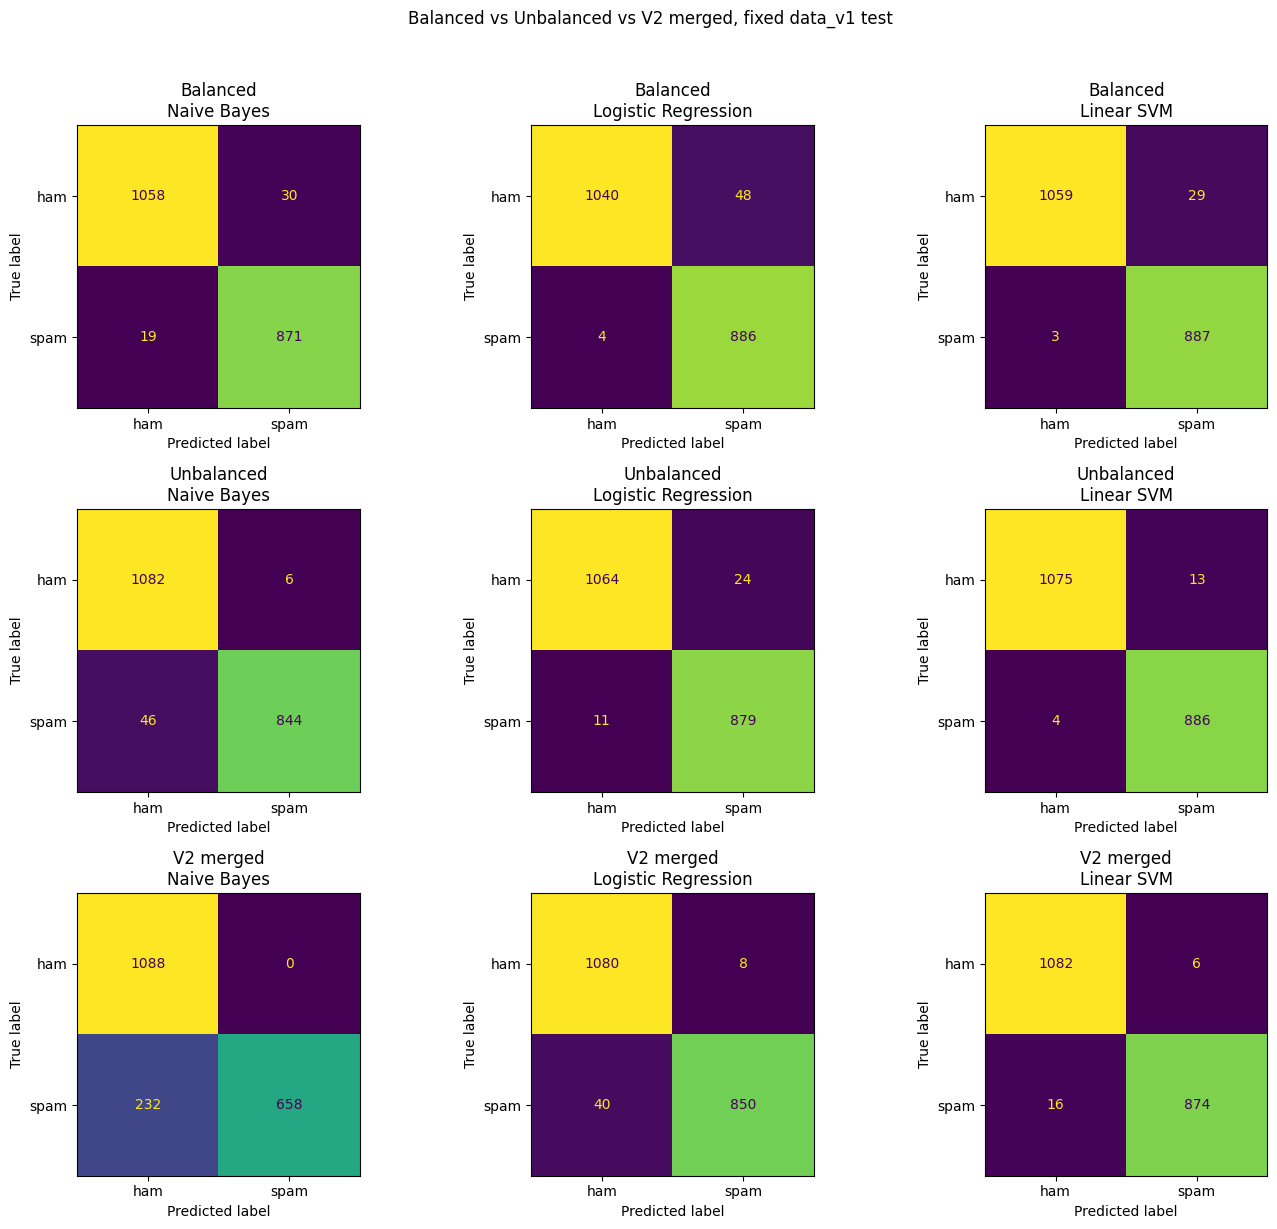

In [6]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

DATA_V2_PROCESSED = PROJECT_ROOT / "data_v2" / "processed" / "emails.csv"
DATA_V2_TEXT_COLUMN = "clean_text"

if not DATA_V2_PROCESSED.exists():
    data_v2 = pd.DataFrame()
    data_v2_merged_train = pd.DataFrame()
    data_v2_results = pd.DataFrame()
    print(f"Data v2 not found yet: {DATA_V2_PROCESSED}")
    print("Run `.venv/bin/python notebooks/crawl_data_v2.py` first, then rerun this cell.")
else:
    data_v2 = pd.read_csv(DATA_V2_PROCESSED).fillna("")
    if "clean_text" not in data_v2.columns:
        data_v2 = preprocess.add_preprocessing_columns(data_v2)
    data_v2 = preprocess.filter_trainable_rows(data_v2).copy()

    base_split_for_v2 = preprocess.split_training_data(data)
    data_v1_train = base_split_for_v2["train_data"].copy()
    data_v1_test = base_split_for_v2["test_data"].copy()

    test_clean_texts = set(data_v1_test[DATA_V2_TEXT_COLUMN].fillna(""))
    data_v2_train_only = data_v2[~data_v2[DATA_V2_TEXT_COLUMN].isin(test_clean_texts)].copy()

    data_v1_train["data_version"] = "data_v1_train"
    data_v2_train_only["data_version"] = "data_v2_extra_ham"
    data_v2_merged_train = (
        pd.concat([data_v1_train, data_v2_train_only], ignore_index=True)
        .drop_duplicates(subset=[DATA_V2_TEXT_COLUMN, "label"])
        .sample(frac=1, random_state=42)
        .reset_index(drop=True)
    )

    data_v2_train_modes = {
        "Balanced": preprocess.balance_dataset(data_v1_train, random_seed=42),
        "Unbalanced": data_v1_train.sample(frac=1, random_state=42).reset_index(drop=True),
        "V2 merged": data_v2_merged_train,
    }

    data_v2_summary = pd.DataFrame(
        [
            {
                "dataset": "data_v1 train before mode transform",
                "rows": len(data_v1_train),
                "ham": int((data_v1_train["label"] == "ham").sum()),
                "spam": int((data_v1_train["label"] == "spam").sum()),
                "source_families": data_v1_train["source_family"].nunique(),
            },
            {
                "dataset": "data_v2 extra ham added to train only",
                "rows": len(data_v2_train_only),
                "ham": int((data_v2_train_only["label"] == "ham").sum()),
                "spam": int((data_v2_train_only["label"] == "spam").sum()),
                "source_families": data_v2_train_only["source_family"].nunique(),
            },
            {
                "dataset": "V2 merged train",
                "rows": len(data_v2_merged_train),
                "ham": int((data_v2_merged_train["label"] == "ham").sum()),
                "spam": int((data_v2_merged_train["label"] == "spam").sum()),
                "source_families": data_v2_merged_train["source_family"].nunique(),
            },
            {
                "dataset": "fixed data_v1 test",
                "rows": len(data_v1_test),
                "ham": int((data_v1_test["label"] == "ham").sum()),
                "spam": int((data_v1_test["label"] == "spam").sum()),
                "source_families": data_v1_test["source_family"].nunique(),
            },
        ]
    )
    display(data_v2_summary)

    mode_summary = []
    for mode_name, train_frame in data_v2_train_modes.items():
        mode_summary.append(
            {
                "training_mode": mode_name,
                "train_rows": len(train_frame),
                "ham_train": int((train_frame["label"] == "ham").sum()),
                "spam_train": int((train_frame["label"] == "spam").sum()),
                "source_families": train_frame["source_family"].nunique(),
            }
        )
    display(pd.DataFrame(mode_summary))
    display(pd.crosstab(data_v2_merged_train["source_family"], data_v2_merged_train["label"]).sort_index())

    data_v2_estimators = {
        "Naive Bayes": MultinomialNB(alpha=1.0),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Linear SVM": LinearSVC(),
    }

    data_v2_rows = []
    data_v2_matrices = []
    for mode_name, train_frame in data_v2_train_modes.items():
        for model_name, estimator in data_v2_estimators.items():
            pipeline = Pipeline(
                [
                    ("tfidf", model_checker.make_tfidf_vectorizer()),
                    ("model", clone(estimator)),
                ]
            )
            pipeline.fit(train_frame[DATA_V2_TEXT_COLUMN], train_frame["label"])
            predictions = pipeline.predict(data_v1_test[DATA_V2_TEXT_COLUMN])
            matrix = confusion_matrix(data_v1_test["label"], predictions, labels=["ham", "spam"])
            tn, fp, fn, tp = matrix.ravel()
            total = tn + fp + fn + tp
            accuracy = (tn + tp) / total if total else 0
            precision = tp / (tp + fp) if (tp + fp) else 0
            recall = tp / (tp + fn) if (tp + fn) else 0
            fpr = fp / (fp + tn) if (fp + tn) else 0
            fnr = fn / (fn + tp) if (fn + tp) else 0
            tnr = tn / (tn + fp) if (tn + fp) else 0

            assert tn + fp == int((data_v1_test["label"] == "ham").sum())
            assert fn + tp == int((data_v1_test["label"] == "spam").sum())
            assert abs(accuracy - accuracy_score(data_v1_test["label"], predictions)) < 1e-12
            assert abs(recall - (tp / (tp + fn) if (tp + fn) else 0)) < 1e-12
            assert abs(fpr - (fp / (fp + tn) if (fp + tn) else 0)) < 1e-12

            data_v2_rows.append(
                {
                    "training_mode": mode_name,
                    "model": model_name,
                    "train_rows": len(train_frame),
                    "ham_train": int((train_frame["label"] == "ham").sum()),
                    "spam_train": int((train_frame["label"] == "spam").sum()),
                    "test_rows": len(data_v1_test),
                    "ham_test": int((data_v1_test["label"] == "ham").sum()),
                    "spam_test": int((data_v1_test["label"] == "spam").sum()),
                    "TN": int(tn),
                    "FP": int(fp),
                    "FN": int(fn),
                    "TP": int(tp),
                    "accuracy": accuracy,
                    "precision": precision,
                    "recall": recall,
                    "TPR": recall,
                    "FPR": fpr,
                    "FNR": fnr,
                    "TNR": tnr,
                }
            )
            data_v2_matrices.append({"training_mode": mode_name, "model": model_name, "matrix": matrix})

    data_v2_results = pd.DataFrame(data_v2_rows)
    metric_columns = ["accuracy", "precision", "recall", "TPR", "FPR", "FNR", "TNR"]
    data_v2_results[metric_columns] = data_v2_results[metric_columns].round(4)
    display(data_v2_results.sort_values(["training_mode", "model"]))

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))
    for axis, payload in zip(axes.ravel(), data_v2_matrices):
        display_obj = ConfusionMatrixDisplay(confusion_matrix=payload["matrix"], display_labels=["ham", "spam"])
        display_obj.plot(ax=axis, values_format="d", colorbar=False)
        axis.set_title(f"{payload['training_mode']}\n{payload['model']}")
    plt.suptitle("Balanced vs Unbalanced vs V2 merged, fixed data_v1 test", y=1.02)
    plt.tight_layout()
    plt.show()



In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9886 entries, 0 to 9885
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   email_id          9886 non-null   object
 1   source            9886 non-null   object
 2   source_family     9886 non-null   object
 3   source_url        9886 non-null   object
 4   local_path        9886 non-null   object
 5   extracted_from    9886 non-null   object
 6   extracted_path    9886 non-null   object
 7   archive_path      9886 non-null   object
 8   label             9886 non-null   object
 9   sender            9886 non-null   object
 10  recipient         9886 non-null   object
 11  subject           9886 non-null   object
 12  body              9886 non-null   object
 13  text              9886 non-null   object
 14  clean_text        9886 non-null   object
 15  raw_char_count    9886 non-null   int64 
 16  clean_char_count  9886 non-null   int64 
 17  clean_word_cou

### Step 1.1 — Missing Data Check

Đếm số giá trị missing theo từng cột của raw dataset và visualize để kiểm tra chất lượng dữ liệu trước preprocessing.

            column  missing_count  missing_percent   dtype
0     archive_path              0              0.0  object
1             body              0              0.0  object
2         email_id              0              0.0  object
3   extracted_from              0              0.0  object
4   extracted_path              0              0.0  object
5            label              0              0.0  object
6       local_path              0              0.0  object
7        recipient              0              0.0  object
8           sender              0              0.0  object
9           source              0              0.0  object
10   source_family              0              0.0  object
11      source_url              0              0.0  object
12         subject              0              0.0  object
13            text              0              0.0  object


/Users/quangmanh/Project/lab01/notebooks/preprocess.py:315: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


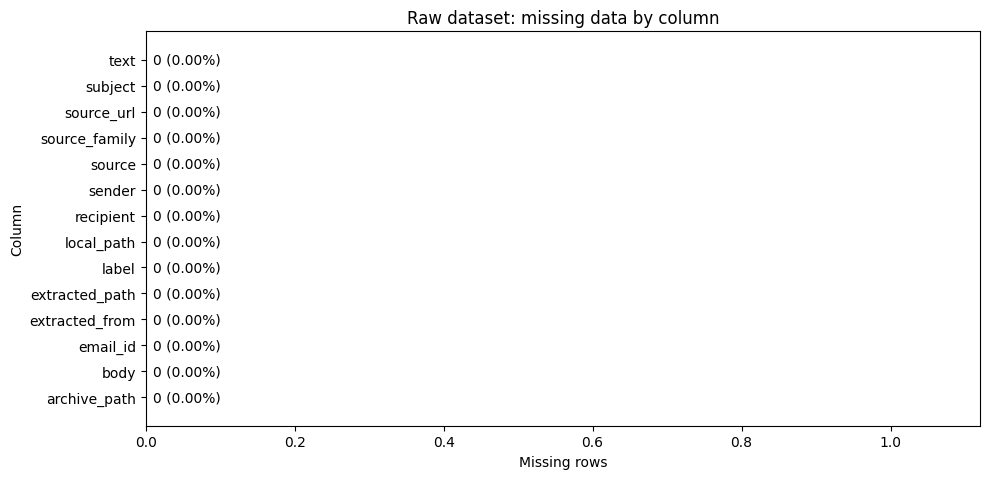

In [9]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

### Step 1.2 — Duplicate Rows Check

Đếm số dòng duplicate trong raw dataset và visualize tỉ lệ unique/duplicate trước preprocessing.

        subset  total_rows  unique_rows  duplicate_rows  duplicate_percent
0  all columns       18807        18807               0                0.0


/Users/quangmanh/Project/lab01/notebooks/preprocess.py:359: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


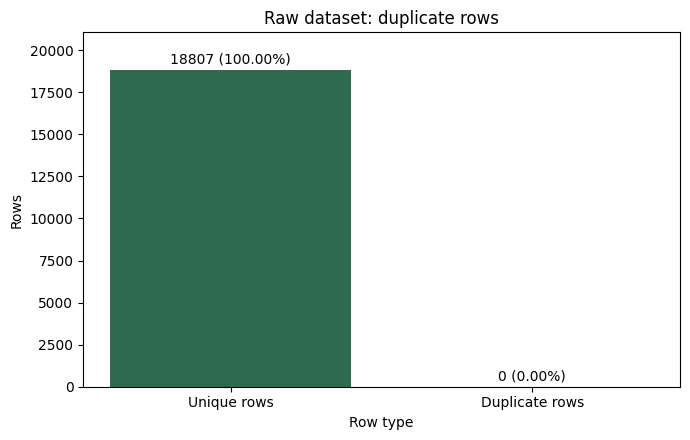

In [11]:
duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")

### Step 1.3 — Label And Source Distribution

In [13]:
display(crawl.label_counts(data))
display(crawl.source_counts(data, top_n=15))

  label  rows
0   ham  5433
1  spam  4453
                        source_family  rows
0                        spamassassin  1338
1                aueb_enron3_spam_ham   985
2                aueb_enron2_spam_ham   976
3    kaggle_email_spam_classification   954
4                aueb_enron1_spam_ham   933
5                aueb_enron4_spam_ham   930
6   huggingface_kimdongh_spam_dataset   913
7                aueb_enron6_spam_ham   896
8              huggingface_enron_spam   781
9                aueb_enron5_spam_ham   761
10         kaggle_enron_email_dataset   419


## Step 2 — Data Processing: Clean Text

Minh hoạ cách email được làm sạch trước khi đưa vào mô hình.

In [15]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

     label  ...                                         clean_text
4170  spam  ...  undeliverable home based business grownups mes...
5809   ham  ...  ilug suse disks thread changed slightly winter...
3023   ham  ...  message-id javamail evans thyme tue mar pst mi...

[3 rows x 5 columns]


In [16]:
raw_example, clean_example = preprocess.example_cleaning()

print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)

Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


## Step 3 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.

In [18]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

  label source_family  ... clean_char_count clean_word_count
0   ham  spamassassin  ...              846              114
1   ham  spamassassin  ...              460               69
2   ham  spamassassin  ...              674              102
3   ham  spamassassin  ...              699              108
4   ham  spamassassin  ...              365               53

[5 rows x 7 columns]


## Step 4 — EDA Before Balance

Tạo bản dữ liệu đã clean và đủ điều kiện train nhưng **chưa balance**. Step này dùng để so sánh phân phối nhãn/source trước khi cân bằng dữ liệu.

In [20]:
full_clean_data, before_balance_data, balanced_preview = preprocess.process_raw_dataset(
    raw_data,
    balance=True,
    mixed_sources_only=True,
    extra_ham_samples=1000,
)

print(f"Full cleaned rows: {len(full_clean_data):,}")
print(f"Trainable rows before balance: {len(before_balance_data):,}")
print(f"Processed preview rows: {len(balanced_preview):,}")
print("Before balance label counts")
display(crawl.label_counts(before_balance_data))
print("After balance + 1000 extra ham label counts")
display(crawl.label_counts(balanced_preview))
display(eda.source_label_table(balanced_preview).head(20))
display(eda.length_summary(balanced_preview))


Full cleaned rows: 18,323
Trainable rows before balance: 12,960
Processed preview rows: 10,002
Before balance label counts
  label  rows
0   ham  8291
1  spam  4669
After balance + 1000 extra ham label counts
  label  rows
0   ham  5501
1  spam  4501
label                      source_family  ham  spam  total  spam_rate
10                          spamassassin  880   500   1380     0.3623
2                   aueb_enron3_spam_ham  493   494    987     0.5005
8       kaggle_email_spam_classification  437   547    984     0.5559
1                   aueb_enron2_spam_ham  490   488    978     0.4990
0                   aueb_enron1_spam_ham  491   456    947     0.4815
3                   aueb_enron4_spam_ham  492   444    936     0.4744
7      huggingface_kimdongh_spam_dataset  471   446    917     0.4864
5                   aueb_enron6_spam_ham  480   423    903     0.4684
6                 huggingface_enron_spam  384   404    788     0.5127
4                   aueb_enron5_spam_ham  462   2

/Users/quangmanh/Project/lab01/notebooks/eda.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:128: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:161: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


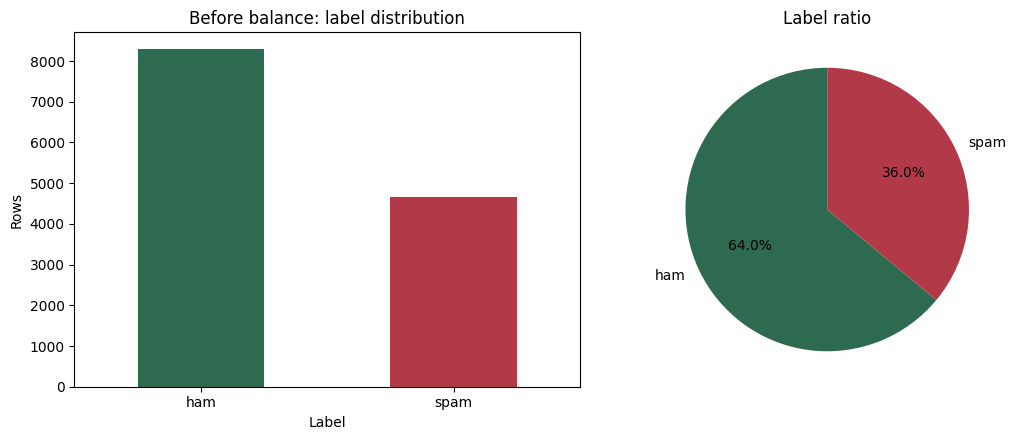

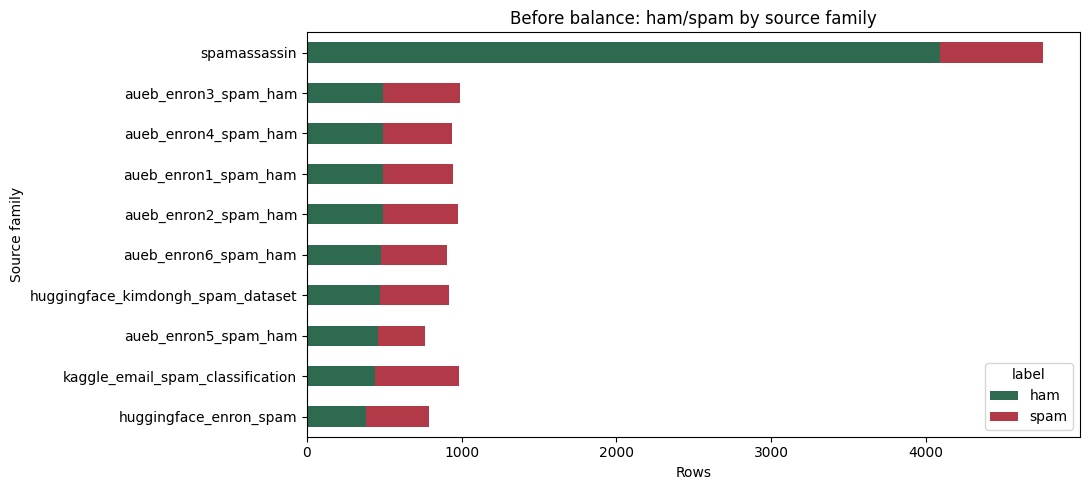

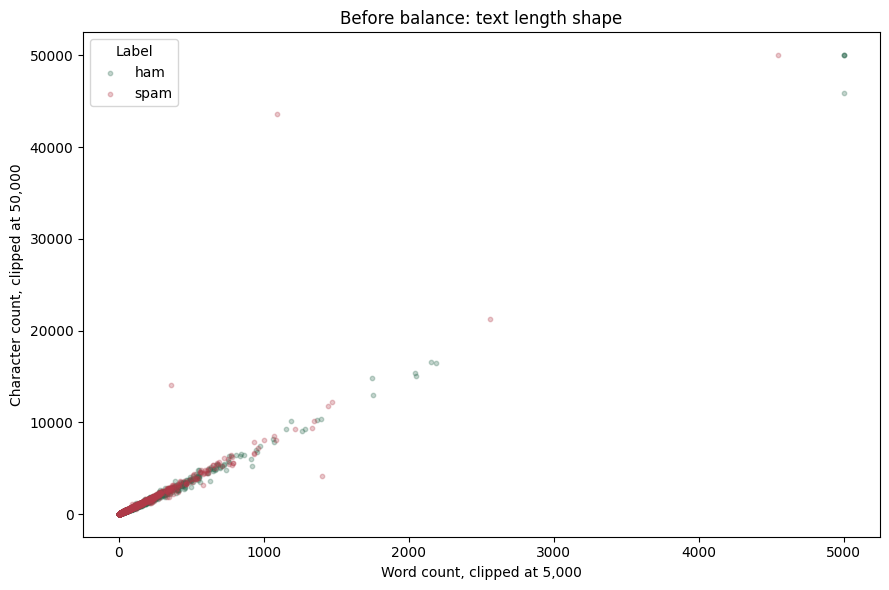

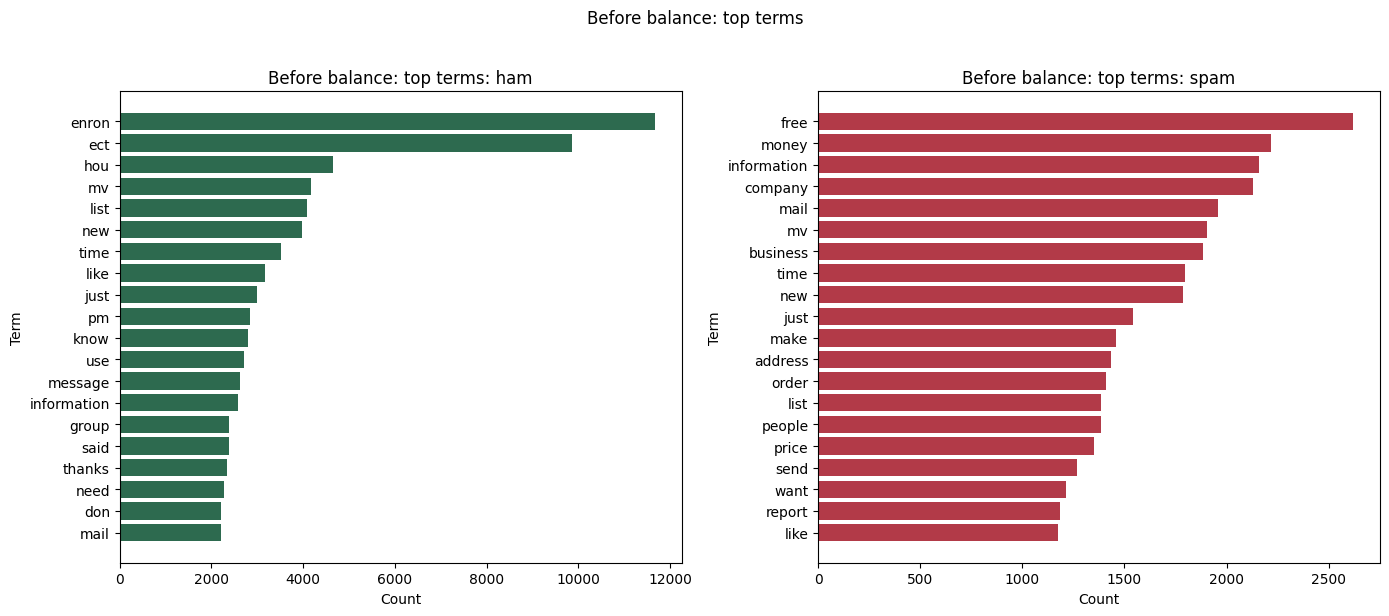

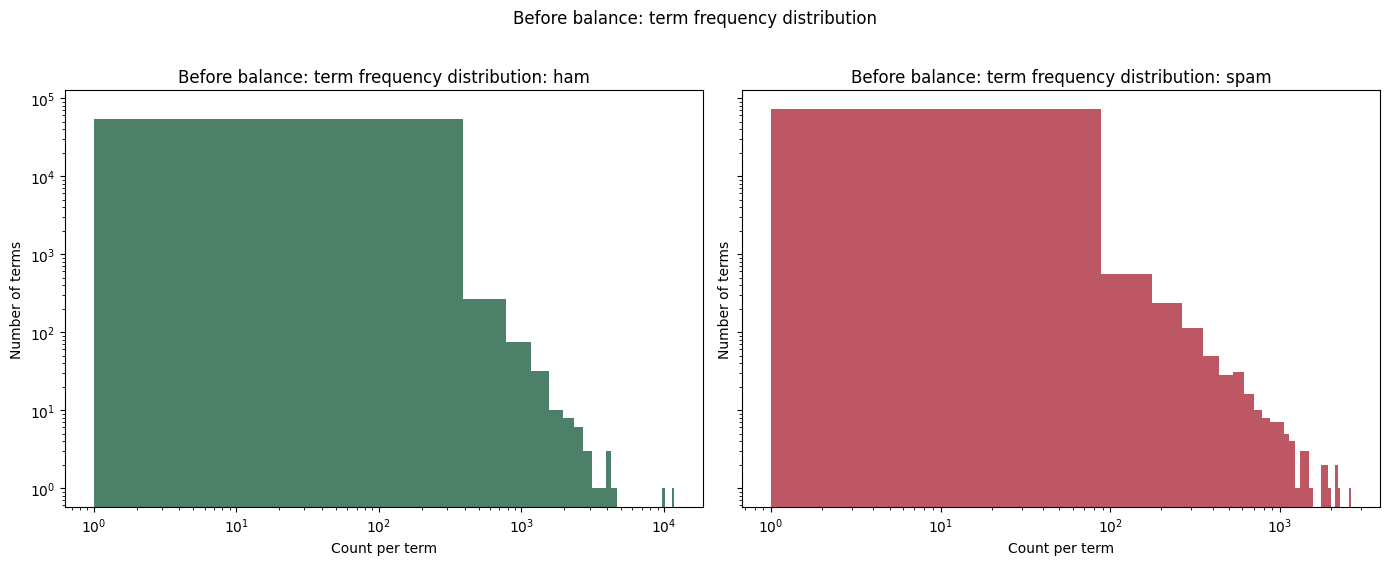

In [21]:
eda = importlib.reload(eda)
eda.plot_eda_overview(before_balance_data, title_prefix="Before balance")

## Step 5 — EDA After Balance

Đây là EDA trên dataset cuối cùng dùng để train/test. Các biểu đồ được vẽ trực tiếp trong notebook.

In [23]:
display(eda.source_label_table(data).head(20))
display(eda.length_summary(data))

label                      source_family  ham  spam  total  spam_rate
10                          spamassassin  845   493   1338     0.3685
2                   aueb_enron3_spam_ham  492   493    985     0.5005
1                   aueb_enron2_spam_ham  490   486    976     0.4980
8       kaggle_email_spam_classification  432   522    954     0.5472
0                   aueb_enron1_spam_ham  482   451    933     0.4834
3                   aueb_enron4_spam_ham  488   442    930     0.4753
7      huggingface_kimdongh_spam_dataset  468   445    913     0.4874
5                   aueb_enron6_spam_ham  475   421    896     0.4699
6                 huggingface_enron_spam  380   401    781     0.5134
4                   aueb_enron5_spam_ham  462   299    761     0.3929
9             kaggle_enron_email_dataset  419     0    419     0.0000
       analysis_char_count  analysis_word_count  subject_chars
count          9886.000000          9886.000000    9886.000000
mean            913.380943        

/Users/quangmanh/Project/lab01/notebooks/eda.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:106: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:128: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/Users/quangmanh/Project/lab01/notebooks/eda.py:161: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


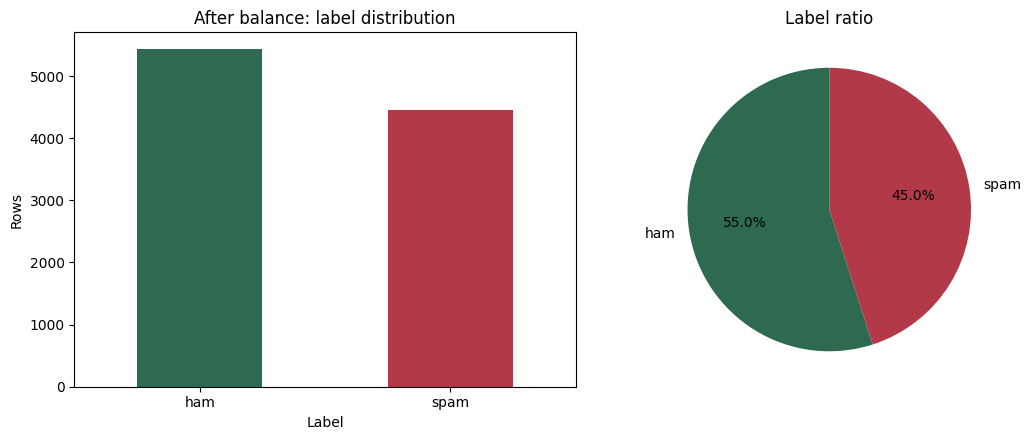

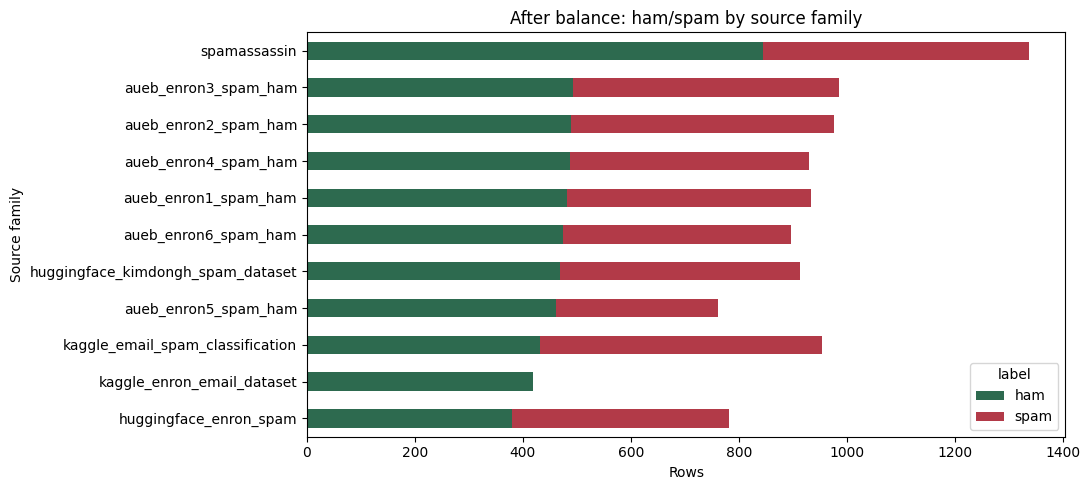

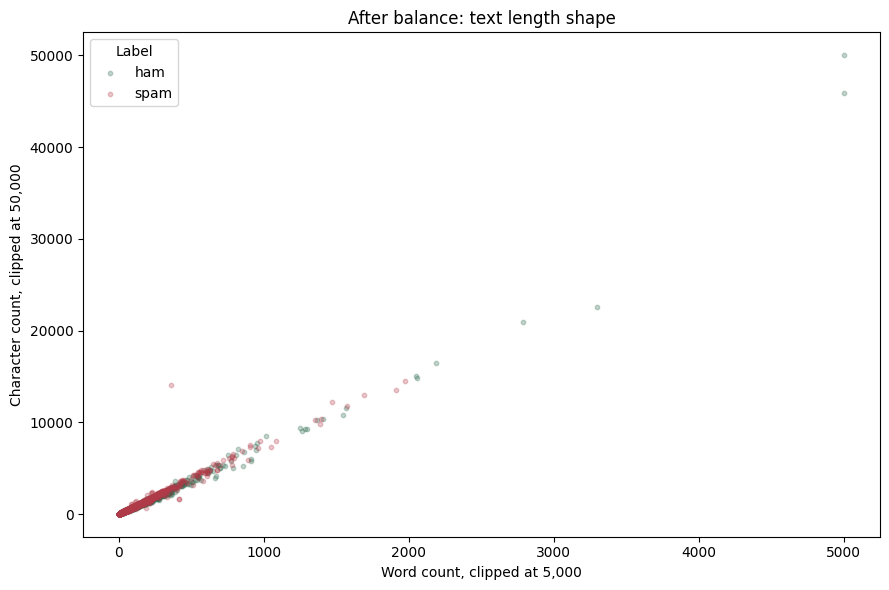

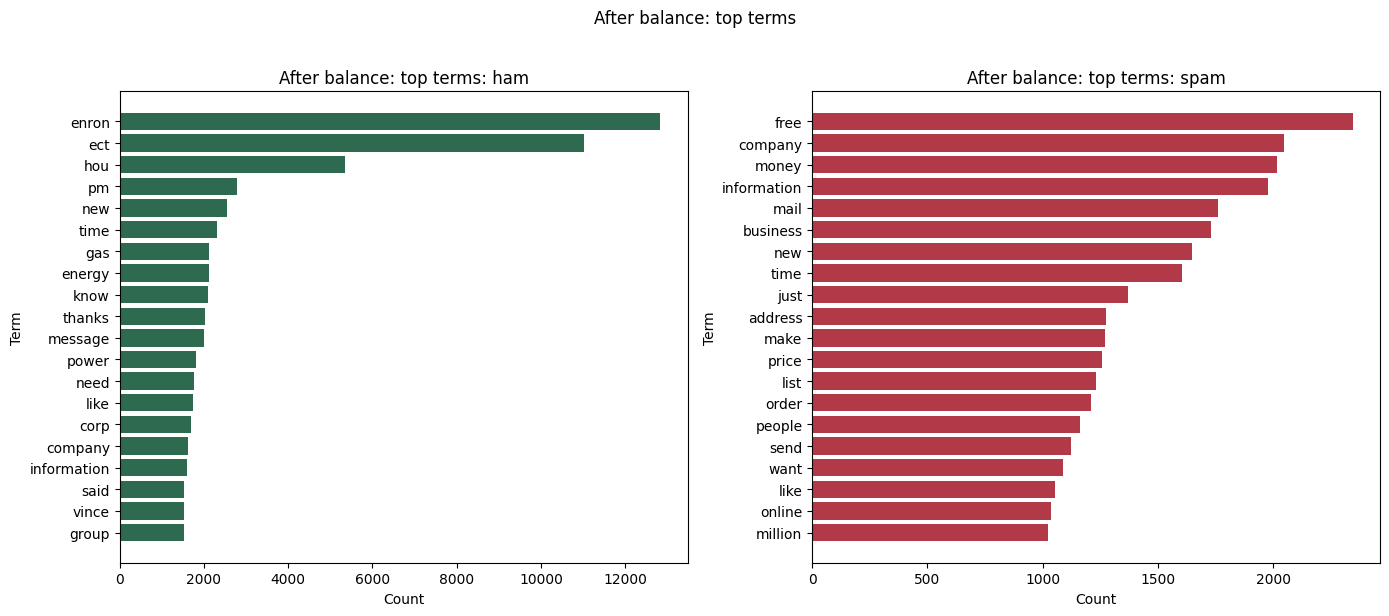

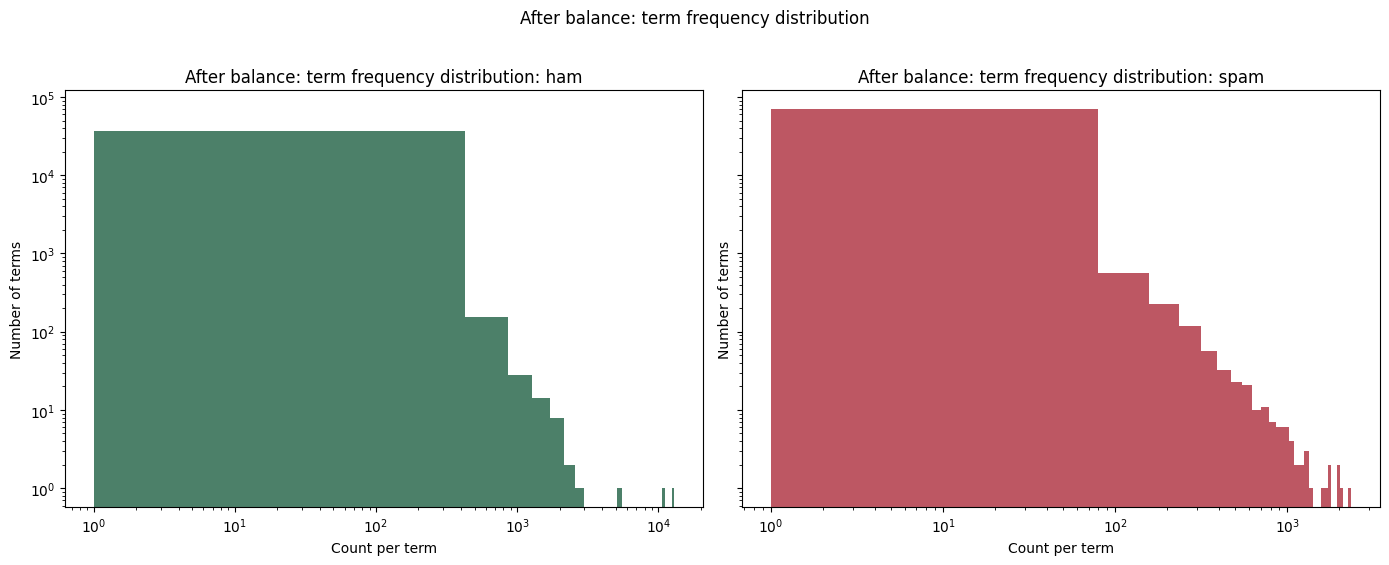

In [24]:
eda = importlib.reload(eda)
eda.plot_eda_overview(data, title_prefix="After balance")

### Step 5 Notes — EDA Reading

## Step 6 — Train/Test Split

Split có stratify theo `source + label` khi đủ dữ liệu, nếu không thì stratify theo label.

In [27]:
split = preprocess.split_training_data(data)
TEXT_COLUMN = split["text_column"]
train_data = split["train_data"]
test_data = split["test_data"]
x_train = split["x_train"]
y_train = split["y_train"]
x_test = split["x_test"]
y_test = split["y_test"]

print(f"Text column: {TEXT_COLUMN}")
print(f"Train rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")
display(preprocess.train_source_crosstab(train_data, top_n=15))

Text column: clean_text
Train rows: 7,908
Test rows: 1,978
label                              ham  spam
source_family                               
aueb_enron1_spam_ham               385   361
aueb_enron2_spam_ham               392   389
aueb_enron3_spam_ham               393   394
aueb_enron4_spam_ham               390   354
aueb_enron5_spam_ham               370   239
aueb_enron6_spam_ham               380   337
huggingface_enron_spam             304   321
huggingface_kimdongh_spam_dataset  374   356
kaggle_email_spam_classification   346   417
kaggle_enron_email_dataset         335     0
spamassassin                       676   395


## Step 7 — Feature Engineering: TF-IDF

TF-IDF không phải là model phân loại. Đây là bước biến email text thành ma trận số để 3 thuật toán bên dưới cùng sử dụng: Naive Bayes, Logistic Regression, và Linear SVM.

In [29]:
tfidf_shape, tfidf_features = model_checker.tfidf_feature_preview(x_train, preview_count=30)

print(f"TF-IDF matrix shape: {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)

TF-IDF matrix shape: 7,908 emails x 151,476 features
Example features:
['000' '000e' '000e mails' '00am' '00pm' '01pm' '01t04' '04pm'
 '04pm dermot' '04t02' '05' '05 08' '06t18' '06t18 game' '08' '08 points'
 '08pm' '0ne' '0ne million' '100k' '105th' '105th congress' '10acpi'
 '10acpi load' '10th' '11b' '11th' '11th floor' '11th larry'
 '11th meeting']


## Step 8 — Three Algorithms From Scratch + Sklearn Checker

Tự code 3 thuật toán: Multinomial Naive Bayes, Logistic Regression, Linear SVM. Lớp `SklearnModelChecker` train các model tương ứng bằng sklearn để kiểm tra lại kết quả. Step này dùng sample train có giới hạn để notebook chạy nhanh khi báo cáo.

### Step 8.1 — Build TF-IDF Matrix For Checking

Tạo một sample nhỏ hơn để 3 model from scratch chạy nhanh trong notebook. Cả 3 thuật toán dùng cùng một ma trận TF-IDF để so sánh công bằng.

In [32]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd

MODEL_SAMPLE_ROWS = 3000
CHECK_SAMPLE_ROWS = 1000

model_train_frame = pd.DataFrame(
    {"text": pd.Series(x_train).reset_index(drop=True), "label": pd.Series(y_train).reset_index(drop=True)}
)
model_test_frame = pd.DataFrame(
    {"text": pd.Series(x_test).reset_index(drop=True), "label": pd.Series(y_test).reset_index(drop=True)}
)

if len(model_train_frame) > MODEL_SAMPLE_ROWS:
    model_train_frame, _ = train_test_split(
        model_train_frame,
        train_size=MODEL_SAMPLE_ROWS,
        random_state=42,
        stratify=model_train_frame["label"],
    )
if len(model_test_frame) > CHECK_SAMPLE_ROWS:
    model_test_frame, _ = train_test_split(
        model_test_frame,
        train_size=CHECK_SAMPLE_ROWS,
        random_state=42,
        stratify=model_test_frame["label"],
    )

scratch_vectorizer = model_checker.make_tfidf_vectorizer()
X_train_scratch = scratch_vectorizer.fit_transform(model_train_frame["text"])
X_test_scratch = scratch_vectorizer.transform(model_test_frame["text"])
y_train_scratch = model_train_frame["label"].to_numpy()
y_test_scratch = model_test_frame["label"].to_numpy()

print(f"Scratch/check train matrix: {X_train_scratch.shape}")
print(f"Scratch/check test matrix: {X_test_scratch.shape}")

Scratch/check train matrix: (3000, 57480)
Scratch/check test matrix: (1000, 57480)


### Step 8.2 — Train Three Models From Scratch

Ba class dưới đây là code tự viết trong `model_from_scratch.py`: `ScratchMultinomialNB`, `ScratchLogisticRegression`, và `ScratchLinearSVM`.

                 algorithm   class_called_in_notebook  scratch_accuracy
0  Multinomial Naive Bayes       ScratchMultinomialNB             0.964
1      Logistic Regression  ScratchLogisticRegression             0.686
2               Linear SVM           ScratchLinearSVM             0.550


<string>:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


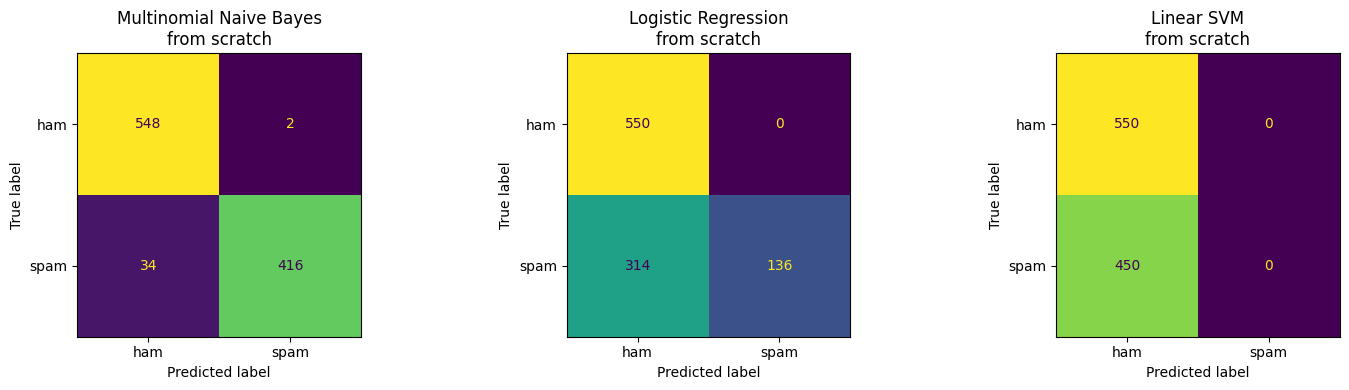

In [34]:
scratch_nb = model_from_scratch.ScratchMultinomialNB(alpha=1.0)
scratch_logistic = model_from_scratch.ScratchLogisticRegression()
scratch_svm = model_from_scratch.ScratchLinearSVM()

scratch_models = {
    "Multinomial Naive Bayes": scratch_nb,
    "Logistic Regression": scratch_logistic,
    "Linear SVM": scratch_svm,
}

scratch_predictions_by_model = {}
for model_name, scratch_model in scratch_models.items():
    scratch_model.fit(X_train_scratch, y_train_scratch)
    scratch_predictions_by_model[model_name] = scratch_model.predict(X_test_scratch)

scratch_summary = pd.DataFrame(
    [
        {
            "algorithm": model_name,
            "class_called_in_notebook": scratch_model.__class__.__name__,
            "scratch_accuracy": accuracy_score(y_test_scratch, scratch_predictions_by_model[model_name]),
        }
        for model_name, scratch_model in scratch_models.items()
    ]
)
display(scratch_summary)

fig, axes = plt.subplots(1, len(scratch_models), figsize=(15, 4))
for axis, (model_name, scratch_predictions) in zip(axes, scratch_predictions_by_model.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_scratch,
        scratch_predictions,
        labels=["ham", "spam"],
        ax=axis,
        colorbar=False,
    )
    axis.set_title(f"{model_name}\nfrom scratch")
plt.tight_layout()
plt.show()

### Step 8.3 — Double Check With Sklearn: Difference Only

`SklearnModelChecker` train 3 model tương ứng bằng sklearn trên đúng cùng ma trận TF-IDF. Ở đây chỉ báo cáo sai lệch giữa bản from scratch và sklearn: chênh lệch accuracy, tỷ lệ prediction khác nhau, và số mẫu dự đoán khác.

In [36]:
sklearn_checker = model_from_scratch.SklearnModelChecker().fit(X_train_scratch, y_train_scratch)

check_rows = []
for model_name, scratch_predictions in scratch_predictions_by_model.items():
    sklearn_predictions = sklearn_checker.predict(model_name, X_test_scratch)
    scratch_accuracy = accuracy_score(y_test_scratch, scratch_predictions)
    sklearn_accuracy = accuracy_score(y_test_scratch, sklearn_predictions)
    mismatch_count = int((scratch_predictions != sklearn_predictions).sum())

    check_rows.append(
        {
            "algorithm": model_name,
            "scratch_accuracy": scratch_accuracy,
            "sklearn_accuracy": sklearn_accuracy,
            "accuracy_diff_abs": abs(scratch_accuracy - sklearn_accuracy),
            "prediction_disagreement_rate": mismatch_count / len(y_test_scratch),
            "mismatch_count": mismatch_count,
            "checked_rows": len(y_test_scratch),
        }
    )

model_check_differences = pd.DataFrame(check_rows)
display(model_check_differences)

                 algorithm  scratch_accuracy  ...  mismatch_count  checked_rows
0  Multinomial Naive Bayes             0.964  ...               0          1000
1      Logistic Regression             0.686  ...             317          1000
2               Linear SVM             0.550  ...             446          1000

[3 rows x 7 columns]


## Step 9 — Model Training

In [38]:
model, predictions, baseline_accuracy, model_accuracy = model_checker.train_project_model(x_train, y_train, x_test, y_test)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.5501
Naive Bayes accuracy: 0.9737


## Step 10 — Evaluate Model

              precision    recall  f1-score   support

         ham       0.96      0.99      0.98      1088
        spam       0.99      0.95      0.97       890

    accuracy                           0.97      1978
   macro avg       0.98      0.97      0.97      1978
weighted avg       0.97      0.97      0.97      1978



<string>:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


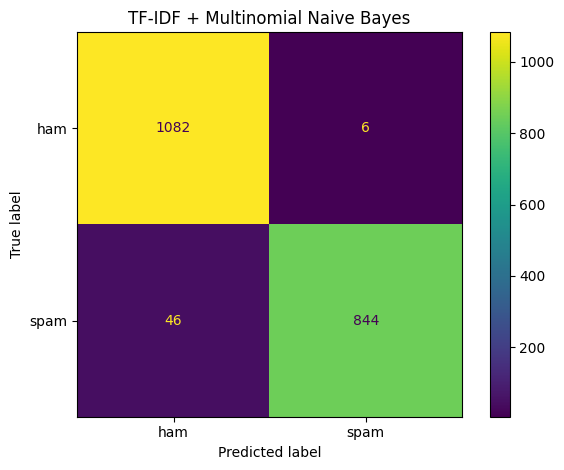

In [40]:
print(eda.classification_report_text(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

### Step 10 Notes — Reading The Metrics

In [42]:
display(eda.top_tokens(model, top_n=15))

label        ham         spam
rank                         
1          enron         free
2            ect        money
3            hou       online
4        hou ect  information
5         thanks         best
6        ect ect         mail
7             pm          new
8           know         time
9        message         want
10      attached         just
11         vince         save
12          time     business
13     questions        order
14           new        offer
15          need      company


In [43]:
display(eda.per_source_scores(test_data, predictions).head(15))

                        source_family  rows  ...  macro_recall  macro_f1
8    kaggle_email_spam_classification   191  ...      0.908472  0.900513
10                       spamassassin   267  ...      0.962655  0.963649
1                aueb_enron2_spam_ham   195  ...      0.963918  0.964042
6              huggingface_enron_spam   156  ...      0.975000  0.974359
4                aueb_enron5_spam_ham   152  ...      0.975000  0.979158
7   huggingface_kimdongh_spam_dataset   183  ...      0.983146  0.983575
2                aueb_enron3_spam_ham   198  ...      0.984848  0.984845
5                aueb_enron6_spam_ham   179  ...      0.988784  0.988784
3                aueb_enron4_spam_ham   186  ...      0.988636  0.989202
0                aueb_enron1_spam_ham   187  ...      1.000000  1.000000
9          kaggle_enron_email_dataset    84  ...      1.000000  1.000000

[11 rows x 6 columns]


## Step 11 — Cross-Source Holdout Check

In [45]:
display(eda.cross_source_holdout(data, TEXT_COLUMN, paths["metrics_dir"]).head(15))

                       holdout_source  rows    labels  accuracy  macro_f1
0      spamassassin_20021010_hard_ham    66       ham  0.257576  0.409639
1      spamassassin_20021010_easy_ham   101       ham  0.653465  0.790419
2      spamassassin_20030228_easy_ham    71       ham  0.690141  0.816667
3    kaggle_email_spam_classification   795  ham,spam  0.905660  0.891409
5              huggingface_enron_spam   652  ham,spam  0.972393  0.970670
6                aueb_enron4_spam_ham   693  ham,spam  0.974026  0.971640
7                aueb_enron6_spam_ham   672  ham,spam  0.974702  0.972724
8                aueb_enron1_spam_ham   705  ham,spam  0.975887  0.973683
9   huggingface_kimdongh_spam_dataset   694  ham,spam  0.982709  0.981308
11               aueb_enron2_spam_ham   737  ham,spam  0.985075  0.983369
4          spamassassin_20021010_spam   213      spam  0.971831  0.985714
12               aueb_enron3_spam_ham   743  ham,spam  0.989233  0.987895
14               aueb_enron5_spam_ham 

## Step 12 — Optional Model Comparison

In [47]:
display(model_checker.compare_models(data, TEXT_COLUMN, sample_rows=50_000))

                 model  accuracy  macro_precision  macro_recall  macro_f1
2           Linear SVM  0.993428         0.993043      0.993717  0.993367
1  Logistic Regression  0.984833         0.984259      0.985189  0.984698
0          Naive Bayes  0.974722         0.977634      0.972144  0.974338


## Step 13 — Validation-Tuned Threshold For Balanced / Unbalanced / V2

So sánh `Balanced`, `Unbalanced`, và `V2 merged` trên cùng một protocol không leakage: `data_v2` chỉ được thêm vào train-pool, threshold được chọn trên validation với ràng buộc `FPR <= 1%`, sau đó mới đánh giá cuối trên test.


Thresholds are selected on validation only; final metrics are evaluated on test only.
                      split  rows   ham  spam
0           train_pool_base  5931  3259  2672
1  data_v2_extra_train_only  5705  5705     0
2                validation  1977  1086   891
3                      test  1978  1088   890
  training_strategy  train_rows  ham_train  spam_train  source_families
0          Balanced        5344       2672        2672               11
1        Unbalanced        5931       3259        2672               11
2         V2 merged       11259       8587        2672               13
   training_strategy  ... can_reach_99_1_on_validation
10         V2 merged  ...                        False
8         Unbalanced  ...                         True
11         V2 merged  ...                        False
1           Balanced  ...                        False
3           Balanced  ...                         True
5         Unbalanced  ...                         True
12         

<string>:88: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


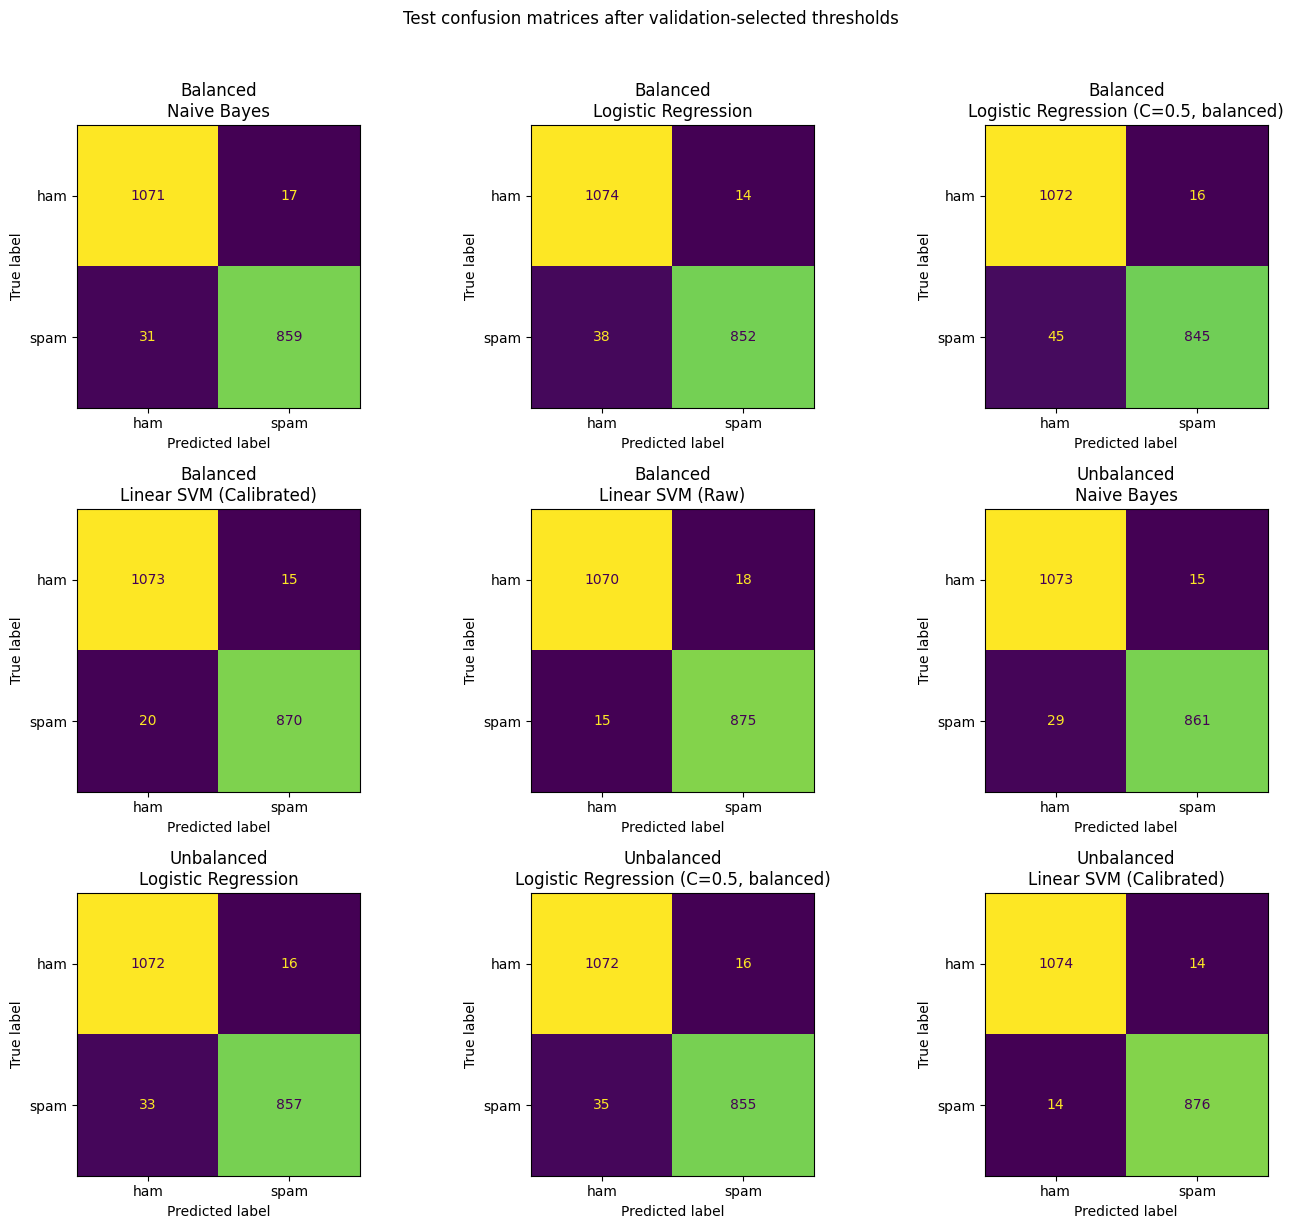

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

TARGET_FPR = 0.01
TARGET_TPR = 0.99
positive_label = "spam"
negative_label = "ham"
matrix_labels = [negative_label, positive_label]

base_threshold_split = preprocess.split_training_data(data)
threshold_train_validation = base_threshold_split["train_data"].copy().reset_index(drop=True)
threshold_test_frame = base_threshold_split["test_data"].copy().reset_index(drop=True)

train_pool, validation_frame = train_test_split(
    threshold_train_validation,
    test_size=0.25,
    random_state=42,
    stratify=threshold_train_validation["label"],
)
train_pool = train_pool.reset_index(drop=True)
validation_frame = validation_frame.reset_index(drop=True)

if DATA_V2_PROCESSED.exists():
    threshold_data_v2 = pd.read_csv(DATA_V2_PROCESSED).fillna("")
    if "clean_text" not in threshold_data_v2.columns:
        threshold_data_v2 = preprocess.add_preprocessing_columns(threshold_data_v2)
    threshold_data_v2 = preprocess.filter_trainable_rows(threshold_data_v2).copy()
    holdout_clean_texts = set(threshold_test_frame[TEXT_COLUMN].fillna("")) | set(validation_frame[TEXT_COLUMN].fillna(""))
    threshold_data_v2_train_only = threshold_data_v2[~threshold_data_v2[TEXT_COLUMN].isin(holdout_clean_texts)].copy()
else:
    threshold_data_v2 = pd.DataFrame()
    threshold_data_v2_train_only = pd.DataFrame()

v2_threshold_train = (
    pd.concat([train_pool, threshold_data_v2_train_only], ignore_index=True)
    .drop_duplicates(subset=[TEXT_COLUMN, "label"])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

threshold_train_modes = {
    "Balanced": preprocess.balance_dataset(train_pool, random_seed=42),
    "Unbalanced": train_pool.sample(frac=1, random_state=42).reset_index(drop=True),
    "V2 merged": v2_threshold_train,
}

print("Thresholds are selected on validation only; final metrics are evaluated on test only.")
display(pd.DataFrame([
    {"split": "train_pool_base", "rows": len(train_pool), "ham": int((train_pool["label"] == "ham").sum()), "spam": int((train_pool["label"] == "spam").sum())},
    {"split": "data_v2_extra_train_only", "rows": len(threshold_data_v2_train_only), "ham": int((threshold_data_v2_train_only["label"] == "ham").sum()) if not threshold_data_v2_train_only.empty else 0, "spam": int((threshold_data_v2_train_only["label"] == "spam").sum()) if not threshold_data_v2_train_only.empty else 0},
    {"split": "validation", "rows": len(validation_frame), "ham": int((validation_frame["label"] == "ham").sum()), "spam": int((validation_frame["label"] == "spam").sum())},
    {"split": "test", "rows": len(threshold_test_frame), "ham": int((threshold_test_frame["label"] == "ham").sum()), "spam": int((threshold_test_frame["label"] == "spam").sum())},
]))

display(pd.DataFrame([
    {"training_strategy": mode_name, "train_rows": len(train_frame), "ham_train": int((train_frame["label"] == "ham").sum()), "spam_train": int((train_frame["label"] == "spam").sum()), "source_families": train_frame["source_family"].nunique()}
    for mode_name, train_frame in threshold_train_modes.items()
]))

# Run threshold experiments using refactored method in model_from_scratch.py
threshold_results, validation_roc_curves, confusion_matrices, threshold_specs = model_checker.run_threshold_experiment(
    train_modes=threshold_train_modes,
    validation_frame=validation_frame,
    test_frame=threshold_test_frame,
    text_column=TEXT_COLUMN,
    target_fpr=TARGET_FPR,
    target_tpr=TARGET_TPR,
    positive_label=positive_label,
)

display_columns = [
    "training_strategy", "model", "score_type", "train_rows", "ham_train", "spam_train",
    "selected_threshold", "validation_FPR", "validation_TPR", "validation_AUC",
    "TN", "FP", "FN", "TP", "accuracy", "precision", "TPR", "FPR", "FNR", "balanced_accuracy",
    "can_reach_99_1_on_validation",
]
display(threshold_results[display_columns].sort_values(["FPR", "TPR"], ascending=[True, False]))

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for axis, payload in zip(axes.ravel(), confusion_matrices):
    display_obj = ConfusionMatrixDisplay(confusion_matrix=payload["matrix"], display_labels=matrix_labels)
    display_obj.plot(ax=axis, colorbar=False, values_format="d")
    axis.set_title(f'{payload["training_strategy"]}\n{payload["model"]}')
plt.suptitle("Test confusion matrices after validation-selected thresholds", y=1.02)
plt.tight_layout()
plt.show()

validation_candidates = threshold_results[threshold_results["validation_FPR"] <= TARGET_FPR].sort_values("validation_TPR", ascending=False)
validation_choice = validation_candidates.iloc[0]
print(
    f'Validation-selected candidate: {validation_choice["training_strategy"]} / {validation_choice["model"]} '
    f'-> validation TPR={validation_choice["validation_TPR"]:.4f}, validation FPR={validation_choice["validation_FPR"]:.4f}; '
    f'test TPR={validation_choice["TPR"]:.4f}, test FPR={validation_choice["FPR"]:.4f}, threshold={validation_choice["selected_threshold"]:.4f}'
)

test_diagnostic = threshold_results[threshold_results["FPR"] <= TARGET_FPR].sort_values("TPR", ascending=False)
if not test_diagnostic.empty:
    best_test = test_diagnostic.iloc[0]
    print(
        f'Diagnostic only - best observed test TPR with test FPR <= 1%: {best_test["training_strategy"]} / {best_test["model"]} '
        f'-> TPR={best_test["TPR"]:.4f}, FPR={best_test["FPR"]:.4f}, threshold={best_test["selected_threshold"]:.4f}'
    )
else:
    best_test = threshold_results.sort_values(["FPR", "TPR"], ascending=[True, False]).iloc[0]
    print(
        f'Diagnostic only - no model keeps test FPR <= 1%. Lowest-FPR option: {best_test["training_strategy"]} / {best_test["model"]} '
        f'-> TPR={best_test["TPR"]:.4f}, FPR={best_test["FPR"]:.4f}'
    )

if ((threshold_results["TPR"] >= TARGET_TPR) & (threshold_results["FPR"] <= TARGET_FPR)).any():
    print("At least one validation-tuned model reaches TPR >= 99% and FPR <= 1% on test.")
else:
    print("No validation-tuned model reaches TPR >= 99% and FPR <= 1% on test; the target still requires stronger features/model or more data quality work.")

## Step 14 — Low-FPR ROC View

Zoom vào vùng FPR thấp để xem model nào giữ được false positive thấp nhất trong khi tăng TPR.

                                           FPR             ...  precision          
training_strategy                     Balanced Unbalanced  ... Unbalanced V2 merged
model                                                      ...                     
Linear SVM (Calibrated)                 0.0138     0.0129  ...     0.9843    0.9778
Linear SVM (Raw)                        0.0165     0.0147  ...     0.9822    0.9822
Logistic Regression                     0.0129     0.0147  ...     0.9817    0.9840
Logistic Regression (C=0.5, balanced)   0.0147     0.0147  ...     0.9816    0.9827
Naive Bayes                             0.0156     0.0138  ...     0.9829    0.9927

[5 rows x 12 columns]


<string>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


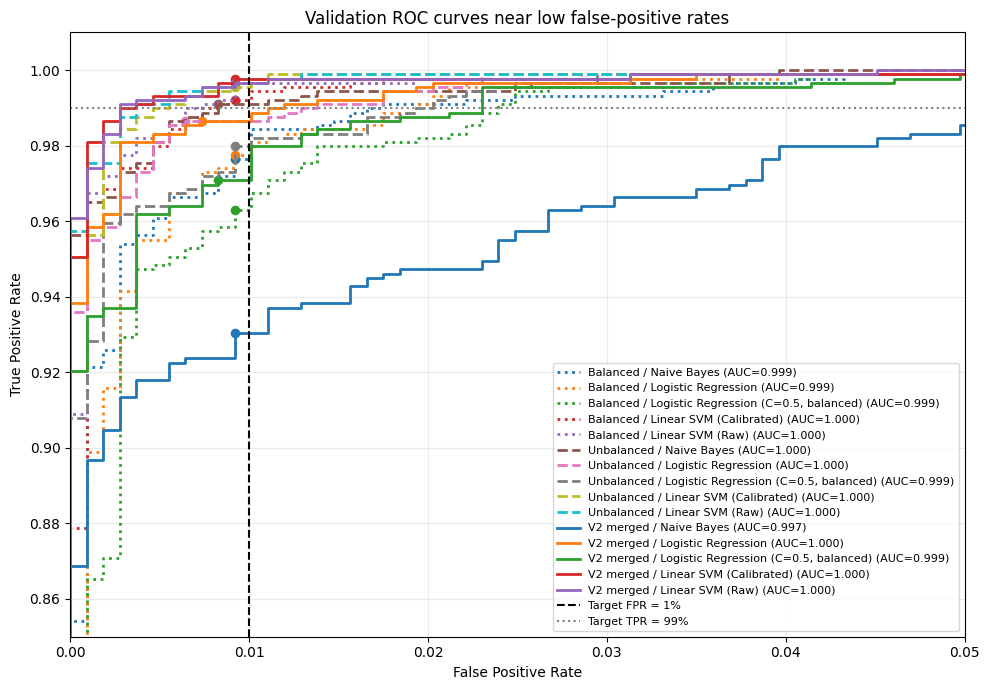

In [51]:
plt.figure(figsize=(10, 7))
line_styles = {"Balanced": ":", "Unbalanced": "--", "V2 merged": "-"}
for curve in validation_roc_curves:
    plt.plot(
        curve["fpr"],
        curve["tpr"],
        linestyle=line_styles.get(curve["training_strategy"], "-"),
        linewidth=2,
        label=f'{curve["training_strategy"]} / {curve["model"]} (AUC={curve["auc"]:.3f})',
    )
    plt.scatter(curve["selected_validation_FPR"], curve["selected_validation_TPR"], s=35)

plt.axvline(TARGET_FPR, color="black", linestyle="--", linewidth=1.5, label="Target FPR = 1%")
plt.axhline(TARGET_TPR, color="gray", linestyle=":", linewidth=1.5, label="Target TPR = 99%")
plt.xlim(0, 0.05)
plt.ylim(0.85, 1.01)
plt.title("Validation ROC curves near low false-positive rates")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.25)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

threshold_strategy_compare = threshold_results.pivot_table(
    index="model",
    columns="training_strategy",
    values=["TPR", "FPR", "precision", "balanced_accuracy"],
    aggfunc="first",
)
display(threshold_strategy_compare)


## Step 15 — Data Failure Analysis For 99/1 Target

Chẩn đoán vì sao model chưa đạt đồng thời `TPR >= 99%` và `FPR <= 1%`. Phần này dùng model được chọn bằng validation, sau đó chỉ phân tích lỗi trên test.

In [53]:
analysis_choice = validation_choice
analysis_spec = next(
    spec for spec in threshold_specs
    if spec["training_strategy"] == analysis_choice["training_strategy"] and spec["model"] == analysis_choice["model"]
)
analysis_pipeline = analysis_spec["pipeline"]
analysis_pipeline.fit(analysis_spec["train_frame"][TEXT_COLUMN], analysis_spec["train_frame"]["label"], **analysis_spec["fit_params"])
analysis_scores, analysis_score_type = model_checker.positive_scores(analysis_pipeline, threshold_test_frame[TEXT_COLUMN], positive_label)
analysis_errors = model_checker.error_analysis_frame(
    threshold_test_frame,
    analysis_scores,
    threshold=analysis_choice["selected_threshold"],
    positive_label=positive_label,
    text_column=TEXT_COLUMN,
)
analysis_metrics = model_checker.metrics_at_threshold(
    threshold_test_frame["label"],
    analysis_scores,
    threshold=analysis_choice["selected_threshold"],
    positive_label=positive_label,
)
assert int((threshold_test_frame["label"] == "ham").sum()) == analysis_metrics["TN"] + analysis_metrics["FP"]
assert int((threshold_test_frame["label"] == "spam").sum()) == analysis_metrics["FN"] + analysis_metrics["TP"]

print(
    f'Failure analysis model: {analysis_choice["training_strategy"]} / {analysis_choice["model"]} '
    f'with threshold={analysis_choice["selected_threshold"]:.4f}, score_type={analysis_score_type}'
)

source_confounding = model_checker.source_label_confounding(before_balance_data)
source_profile_summary = source_confounding.groupby("source_profile").agg(
    sources=("source_family", "count"),
    rows=("total", "sum"),
    ham=("ham", "sum"),
    spam=("spam", "sum"),
).reset_index().sort_values("rows", ascending=False)
display(source_profile_summary)
display(source_confounding.sort_values("total", ascending=False).head(15))

source_errors = model_checker.source_error_summary(analysis_errors)
for column in ["FPR", "FNR", "TPR"]:
    source_errors[column] = source_errors[column].round(4)
display(source_errors.head(15))

overlap_summary = model_checker.score_overlap_summary(
    analysis_errors,
    threshold=analysis_choice["selected_threshold"],
    window=0.05,
)
for column in ["near_threshold_rate", "score_min", "score_median", "score_max"]:
    overlap_summary[column] = overlap_summary[column].round(4)
display(overlap_summary)

plt.figure(figsize=(10, 5.5))
for label, group in analysis_errors.groupby("label"):
    plt.hist(group["score"], bins=40, alpha=0.55, density=True, label=label)
plt.axvline(analysis_choice["selected_threshold"], color="black", linestyle="--", linewidth=1.5, label="selected threshold")
if analysis_score_type == "probability":
    plt.xlim(max(0, analysis_choice["selected_threshold"] - 0.25), min(1, analysis_choice["selected_threshold"] + 0.25))
else:
    plt.xlim(analysis_choice["selected_threshold"] - 1.0, analysis_choice["selected_threshold"] + 1.0)
plt.title("Score overlap near selected threshold")
plt.xlabel("Spam score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

error_columns = ["error_type", "label", "prediction", "score", "threshold_distance", "source_family", "subject", "snippet"]
fp_near = analysis_errors[analysis_errors["error_type"] == "FP"].sort_values("threshold_distance").head(10).copy()
fn_near = analysis_errors[analysis_errors["error_type"] == "FN"].sort_values("threshold_distance").head(10).copy()
for frame in [fp_near, fn_near]:
    frame["score"] = frame["score"].round(4)
    frame["threshold_distance"] = frame["threshold_distance"].round(4)
print("False positives closest to threshold")
display(fp_near[error_columns])
print("False negatives closest to threshold")
display(fn_near[error_columns])

conflicts = model_checker.conflicting_clean_texts(before_balance_data, text_column=TEXT_COLUMN, top_n=20)
display(conflicts)

fp_tokens = model_checker.top_error_tokens(analysis_errors, "FP", text_column=TEXT_COLUMN, top_n=20)
fn_tokens = model_checker.top_error_tokens(analysis_errors, "FN", text_column=TEXT_COLUMN, top_n=20)
error_tokens = pd.concat([fp_tokens, fn_tokens], ignore_index=True)
display(error_tokens)

ham_only_rows = int(source_profile_summary.loc[source_profile_summary["source_profile"].eq("ham-only"), "rows"].sum())
ham_only_sources = int(source_profile_summary.loc[source_profile_summary["source_profile"].eq("ham-only"), "sources"].sum())
near_ham = int(overlap_summary.loc[overlap_summary["label"].eq("ham"), "near_threshold_rows"].iloc[0])
near_spam = int(overlap_summary.loc[overlap_summary["label"].eq("spam"), "near_threshold_rows"].iloc[0])
conflict_rows = int(conflicts["rows"].sum()) if not conflicts.empty else 0
issue_summary = pd.DataFrame([
    {
        "issue": "Source-label confounding",
        "evidence": f"{ham_only_sources} ham-only source families with {ham_only_rows} rows; source profiles are highly label-skewed.",
        "impact": "Model can learn source/domain style instead of pure spam semantics, hurting cross-source generalization.",
        "next_action": "Evaluate by source family, reduce source artifacts, and add mixed-source validation/holdout checks.",
    },
    {
        "issue": "Score overlap around threshold",
        "evidence": f"Near threshold (+/-0.05): {near_ham} ham and {near_spam} spam rows.",
        "impact": "Raising TPR pulls overlapping ham across threshold, so FPR exceeds 1%.",
        "next_action": "Add stronger features such as URL/header/domain signals or a better semantic model.",
    },
    {
        "issue": "False positives / false negatives are source-patterned",
        "evidence": f"Top source errors include {', '.join(source_errors.head(5)['source_family'].astype(str))}.",
        "impact": "Some sources dominate residual errors; global threshold cannot fix all source-specific score shifts.",
        "next_action": "Inspect source-specific samples, label noise, and consider source-aware validation or normalization.",
    },
    {
        "issue": "Exact conflicting clean_text labels",
        "evidence": f"{len(conflicts)} conflicting clean_text groups shown; total duplicate conflict rows in top list: {conflict_rows}.",
        "impact": "If conflicts exist, no threshold can classify identical text into both labels correctly.",
        "next_action": "Deduplicate/resolve conflicting labels before final training.",
    },
    {
        "issue": "Token/artifact-driven errors",
        "evidence": "FP/FN top-token tables show the words most associated with residual mistakes.",
        "impact": "TF-IDF may be reacting to artifacts rather than robust intent cues.",
        "next_action": "Extend cleaning and add robust non-text features; review FP/FN samples manually.",
    },
])
display(issue_summary)

Traceback (most recent call last):
  File "/Users/quangmanh/Project/lab01/scratch/run_notebook.py", line 51, in <module>
    exec(source, globals_dict)
  File "<string>", line 3, in <module>
NameError: name 'threshold_specs' is not defined. Did you mean: 'threshold_results'?
Error in cell 53: name 'threshold_specs' is not defined


## Step 16 — Save And Reuse The Model

In [55]:
saved_model_path = model_checker.save_model(model, paths["model"])
print(f"Saved model to {saved_model_path.relative_to(PROJECT_ROOT)}")

Saved model to models/spam_nb.joblib


In [56]:
display(model_checker.predict_new_emails(paths["model"]))

                                          email_text  ... confidence
0  Win cash now! Click the prize link and claim y...  ...     0.8394
1  Hi team, attached are the meeting notes and ne...  ...     0.9646

[2 rows x 4 columns]


## Step 17 — Project Reports

In [58]:
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))

print("\nSaved classification report:\n")
print(crawl.read_classification_report(paths["metrics_dir"]))

                                              report  status
0  data/processed/metrics/preprocessing_balance_r...  exists
1   data/processed/metrics/classification_report.txt  exists
2            data/processed/metrics/model_summary.md  exists
3  data/processed/metrics/per_source_classificati...  exists
4  data/processed/metrics/cross_source_holdout_re...  exists

Saved classification report:

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       896
        spam       0.98      0.98      0.98       892

    accuracy                           0.98      1788
   macro avg       0.98      0.98      0.98      1788
weighted avg       0.98      0.98      0.98      1788

